In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("customer_segmentation.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Columns:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

Data Types:
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
Nu

In [6]:
missing = df.isnull().sum()

print(missing[missing > 0])

Income    24
dtype: int64


In [7]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum().sort_values(ascending=False))

Missing values before cleaning:
Income                 24
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [8]:
# Fill missing Income values with median
df["Income"] = df["Income"].fillna(df["Income"].median())

print("Missing values in Income after cleaning:")
print(df["Income"].isnull().sum())

Missing values in Income after cleaning:
0


In [9]:
# Create Age column
df["Age"] = 2026 - df["Year_Birth"]

# Check the result
df[["Year_Birth", "Age"]].head()

,Year_Birth,Age
0,1957,69
1,1954,72
2,1965,61
3,1984,42
4,1981,45


In [10]:
print(df["Age"].describe())

count    2240.000000
mean       57.194196
std        11.984069
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64


In [11]:
print("Customers with Age > 100:")
print(df[df["Age"] > 100][["ID", "Year_Birth", "Age"]])

Customers with Age > 100:
        ID  Year_Birth  Age
192   7829        1900  126
239  11004        1893  133
339   1150        1899  127


In [12]:
# Remove unrealistic age records
df = df[df["Age"] <= 100].copy()

print("New dataset shape:", df.shape)
print("Maximum age:", df["Age"].max())

New dataset shape: (2237, 30)
Maximum age: 86


In [13]:
# Total amount spent by each customer

spending_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df["Total_Spending"] = df[spending_cols].sum(axis=1)

df[["Total_Spending"] + spending_cols].head()

,Total_Spending,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,1617,635,88,546,172,88,88
1,27,11,1,6,2,1,6
2,776,426,49,127,111,21,42
3,53,11,4,20,10,3,5
4,422,173,43,118,46,27,15


In [14]:
# Total number of purchases across channels

purchase_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases"
]

df["Total_Purchases"] = df[purchase_cols].sum(axis=1)

df[["Total_Purchases"] + purchase_cols].head()

,Total_Purchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases
0,25,8,10,4,3
1,6,1,1,2,2
2,21,8,2,10,1
3,8,2,0,4,2
4,19,5,3,6,5


In [15]:
print(df[["Age", "Income", "Total_Spending", "Total_Purchases"]].describe())

               Age         Income  Total_Spending  Total_Purchases
count  2237.000000    2237.000000     2237.000000      2237.000000
mean     57.098346   52227.407689      605.743406        14.870809
std      11.701917   25043.266830      601.840466         7.676593
min      30.000000    1730.000000        5.000000         0.000000
25%      49.000000   35523.000000       69.000000         8.000000
50%      56.000000   51381.500000      396.000000        15.000000
75%      67.000000   68281.000000     1045.000000        21.000000
max      86.000000  666666.000000     2525.000000        44.000000


In [16]:
# Check customers with unusually high income
df[df["Income"] > 200000][["ID", "Income", "Age", "Total_Spending", "Total_Purchases"]]

,ID,Income,Age,Total_Spending,Total_Purchases
2233,9432,666666.0,49,62,11


In [17]:
# Remove extreme income outlier
df = df[df["Income"] <= 200000].copy()

print("Dataset shape after removing income outlier:", df.shape)
print("Maximum income:", df["Income"].max())

Dataset shape after removing income outlier: (2236, 32)
Maximum income: 162397.0


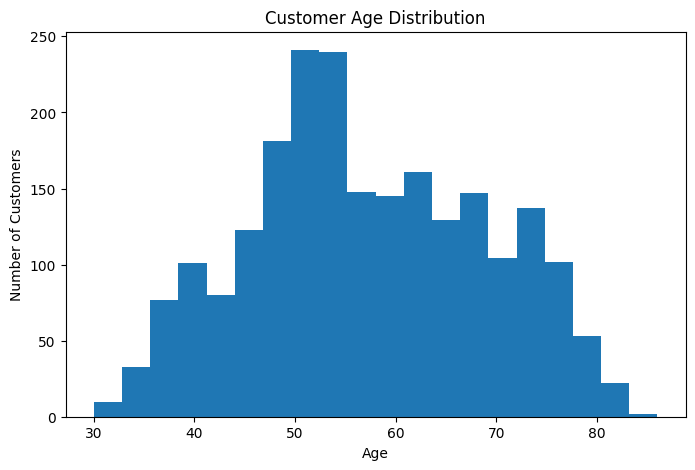

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["Age"], bins=20)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

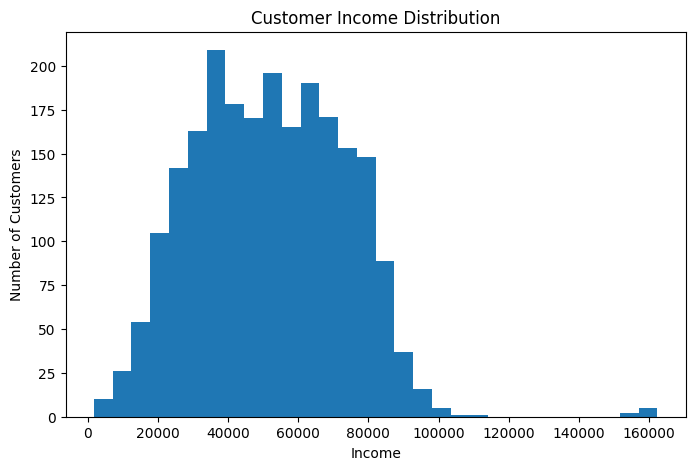

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(df["Income"], bins=30)

plt.title("Customer Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.show()

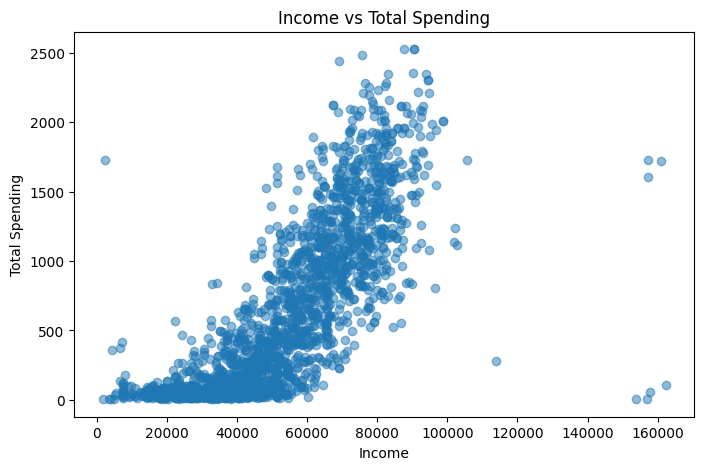

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Income"], df["Total_Spending"], alpha=0.5)

plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")

plt.show()

In [21]:
purchase_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases"
]

purchase_means = df[purchase_cols].mean()

print(purchase_means)

NumWebPurchases        4.087657
NumCatalogPurchases    2.663238
NumStorePurchases      5.795617
NumDealsPurchases      2.326029
dtype: float64


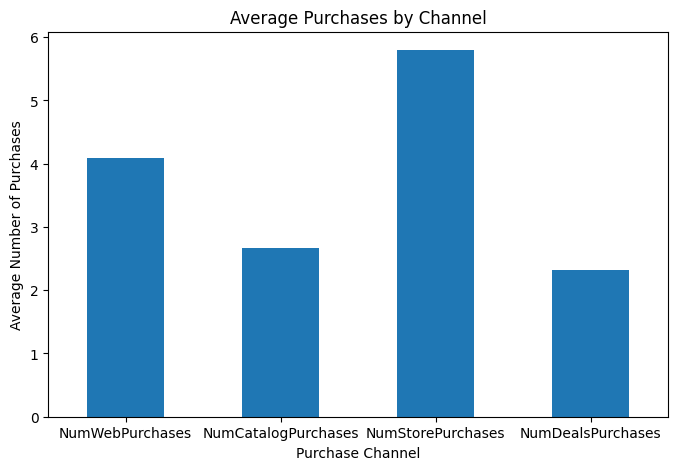

In [22]:
plt.figure(figsize=(8, 5))

purchase_means.plot(kind="bar")

plt.title("Average Purchases by Channel")
plt.xlabel("Purchase Channel")
plt.ylabel("Average Number of Purchases")

plt.xticks(rotation=0)
plt.show()

In [23]:
# Features selected for customer segmentation

features = [
    "Age",
    "Income",
    "Total_Spending",
    "Total_Purchases"
]

X = df[features].copy()

print("Features used for clustering:")
print(X.head())

print("\nShape:", X.shape)

Features used for clustering:
   Age   Income  Total_Spending  Total_Purchases
0   69  58138.0            1617               25
1   72  46344.0              27                6
2   61  71613.0             776               21
3   42  26646.0              53                8
4   45  58293.0             422               19

Shape: (2236, 4)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.01686817  0.28894655  1.6801763   1.31933993]
 [ 1.27326389 -0.262003   -0.9622024  -1.15585714]
 [ 0.33314626  0.91842301  0.28254077  0.79824581]
 [-1.2906933  -1.18218313 -0.91899369 -0.89531008]
 [-1.03429758  0.29618728 -0.30576241  0.53769875]]


In [26]:
print("Scaling successful!")
print("Shape:", X_scaled.shape)

Scaling successful!
Shape: (2236, 4)


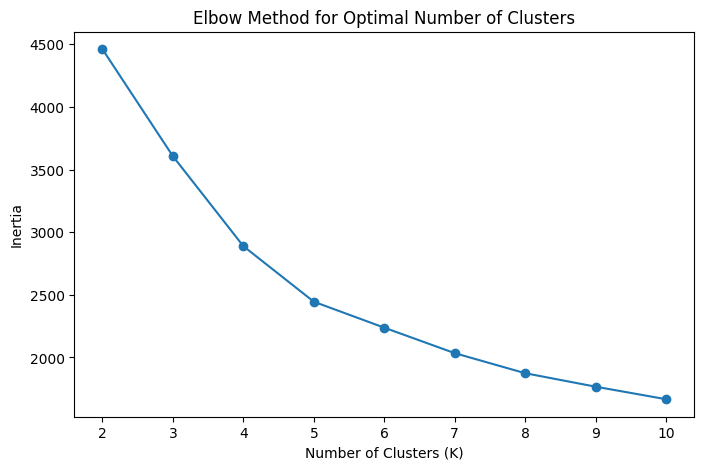

In [27]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.show()

In [28]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df["Cluster"].value_counts().sort_index())

Cluster
0    505
1    701
2    541
3    489
Name: count, dtype: int64


In [29]:
cluster_profile = df.groupby("Cluster")[features].mean().round(2)

cluster_profile

,Age,Income,Total_Spending,Total_Purchases
Cluster,,,,
0,69.37,69215.04,1111.88,21.65
1,47.98,31794.07,103.62,8.00
2,49.11,70426.25,1167.41,21.43
3,66.35,42585.29,182.58,10.48


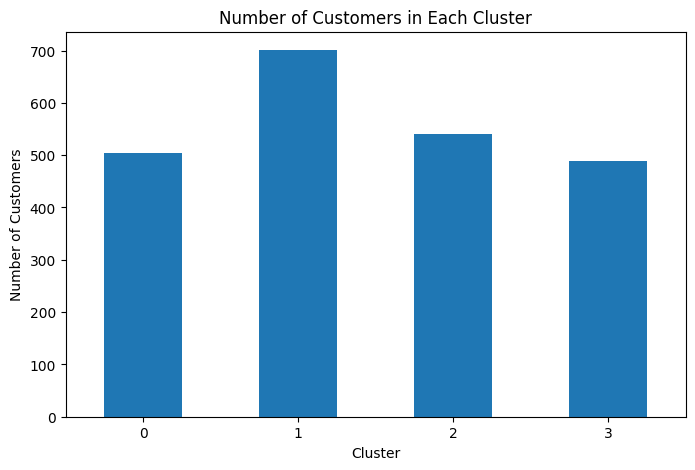

In [30]:
cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind="bar")
plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

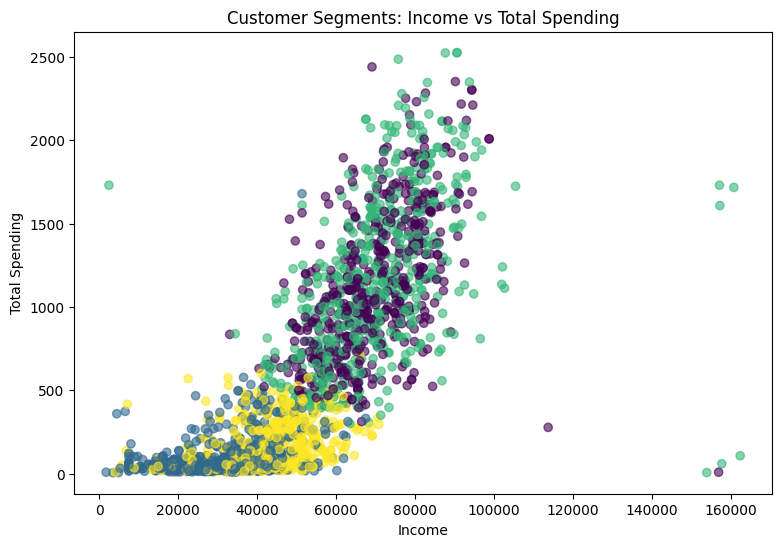

In [31]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Income"],
    df["Total_Spending"],
    c=df["Cluster"],
    alpha=0.6
)

plt.title("Customer Segments: Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.show()

In [32]:
cluster_summary = df.groupby("Cluster")[[
    "Age",
    "Income",
    "Total_Spending",
    "Total_Purchases"
]].mean().round(2)

cluster_summary

,Age,Income,Total_Spending,Total_Purchases
Cluster,,,,
0,69.37,69215.04,1111.88,21.65
1,47.98,31794.07,103.62,8.00
2,49.11,70426.25,1167.41,21.43
3,66.35,42585.29,182.58,10.48


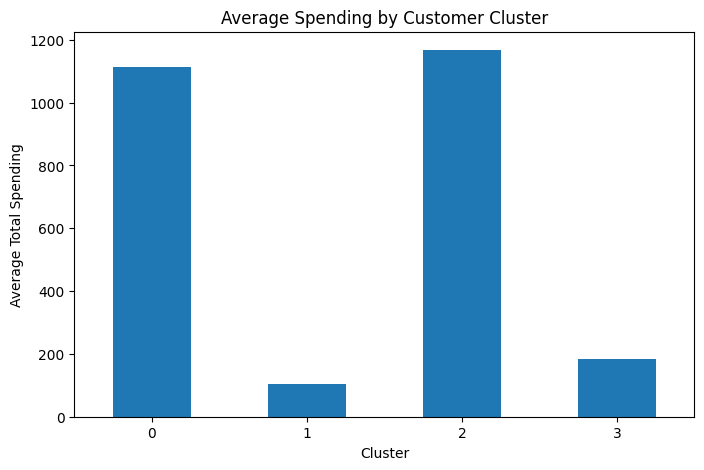

In [33]:
cluster_summary["Total_Spending"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Spending by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=0)
plt.show()

In [34]:
cluster_names = {
    0: "Older High-Value Customers",
    1: "Low-Value / Budget Customers",
    2: "Young High-Value Customers",
    3: "Older Low-Engagement Customers"
}

df["Segment"] = df["Cluster"].map(cluster_names)

df[["Cluster", "Segment"]].drop_duplicates().sort_values("Cluster")

,Cluster,Segment
0,0,Older High-Value Customers
3,1,Low-Value / Budget Customers
4,2,Young High-Value Customers
1,3,Older Low-Engagement Customers


In [35]:
for cluster in sorted(df["Cluster"].unique()):
    print(f"\nCluster {cluster} - {cluster_names[cluster]}")
    print(df[df["Cluster"] == cluster][[
        "Age",
        "Income",
        "Total_Spending",
        "Total_Purchases"
    ]].mean().round(2))


Cluster 0 - Older High-Value Customers
Age                   69.37
Income             69215.04
Total_Spending      1111.88
Total_Purchases       21.65
dtype: float64

Cluster 1 - Low-Value / Budget Customers
Age                   47.98
Income             31794.07
Total_Spending       103.62
Total_Purchases        8.00
dtype: float64

Cluster 2 - Young High-Value Customers
Age                   49.11
Income             70426.25
Total_Spending      1167.41
Total_Purchases       21.43
dtype: float64

Cluster 3 - Older Low-Engagement Customers
Age                   66.35
Income             42585.29
Total_Spending       182.58
Total_Purchases       10.48
dtype: float64


In [36]:
df.to_csv("customer_segmentation_final.csv", index=False)

print("Final segmented dataset saved successfully!")

Final segmented dataset saved successfully!


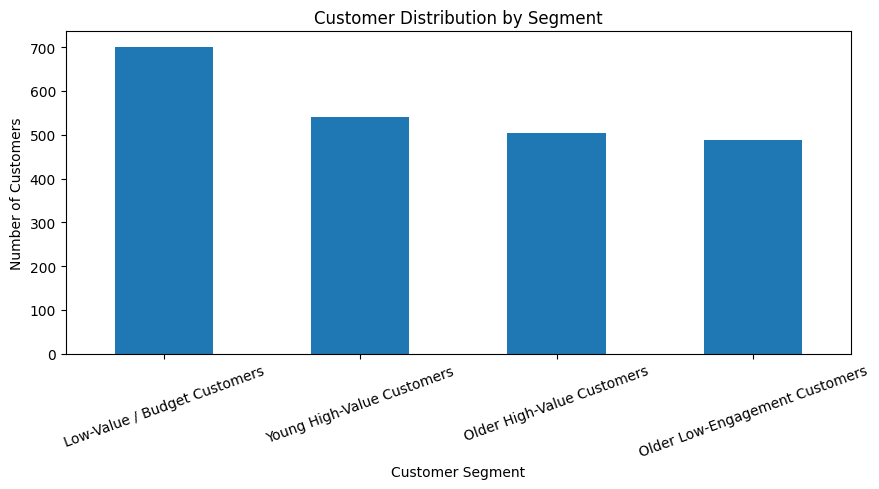

In [37]:
import matplotlib.pyplot as plt

segment_counts = df["Segment"].value_counts()

plt.figure(figsize=(9, 5))
segment_counts.plot(kind="bar")
plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Objective:
To segment customers into meaningful groups based on demographic and purchasing behavior using K-Means clustering.

Features Used:

Age
Income
Total Spending
Total Purchases

Data Preparation:
Missing income values were replaced using the median. Unrealistic age values and an extreme income outlier were removed. Two behavioral features, Total Spending and Total Purchases, were created.

Methodology:

Data Cleaning
Exploratory Data Analysis
Feature Engineering
Feature Scaling using StandardScaler
K-Means Clustering
Cluster Profiling
Data Visualization

Result:
Four customer segments were identified based on differences in age, income, spending, and purchasing behavior.

Conclusion:
Customer segmentation can help businesses understand different customer groups and develop more targeted marketing and customer-engagement strategies.
